# Cresanti Notebook for NSA Ceilometer Data

## Setup

In [2]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import getpass
import act
import datetime

## Data Download

In [3]:
# Note - recommended ARM Live token to be set as an environmental variable

# Check for env variables, otherwise set your username and token here!
if "ARM_USERNAME" in os.environ:
    arm_username = os.getenv("ARM_USERNAME")
else:
    arm_username = input("Enter ARM username: ").strip()
if "ARM_TOKEN" in os.environ:
    arm_token = os.getenv("ARM_TOKEN")
else:
    arm_token = getpass.getpass("Enter ARM token (hidden): ").strip()

# Set the datastream and start/enddates
ceil_datastream = 'nsaceilC1.b1'

startdate = '2015-06-13'
enddate = '2015-06-13'

# Use ACT to easily download the data.  Watch for the data citation!  Show some support
# for ARM's instrument experts and cite their data if you use it in a publication
result_ceil = act.discovery.download_arm_data(arm_username, arm_token, ceil_datastream, startdate, enddate)

Enter ARM username:  acresanti
Enter ARM token (hidden):  ········


[DOWNLOADING] nsaceilC1.b1.20150613.000000.nc

If you use these data to prepare a publication, please cite:

Zhang, D., Ermold, B., & Morris, V. Ceilometer (CEIL), 2015-06-13 to 2015-06-13,
North Slope Alaska (NSA), Central Facility, Barrow AK (C1). Atmospheric
Radiation Measurement (ARM) User Facility. https://doi.org/10.5439/1181954



## Visualize Data

In [62]:
# Read data
ceil_ds = act.io.arm.read_arm_netcdf(result_ceil)

# Adjust ceilometer data for plotting
ceil_ds = act.corrections.ceil.correct_ceil(ceil_ds, -9999.0)

In [63]:
# Set time range
time_rng=(datetime.datetime(2015, 6, 13, 18, 0), datetime.datetime(2015, 6, 13, 23, 59))

/opt/conda/lib/python3.11/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)


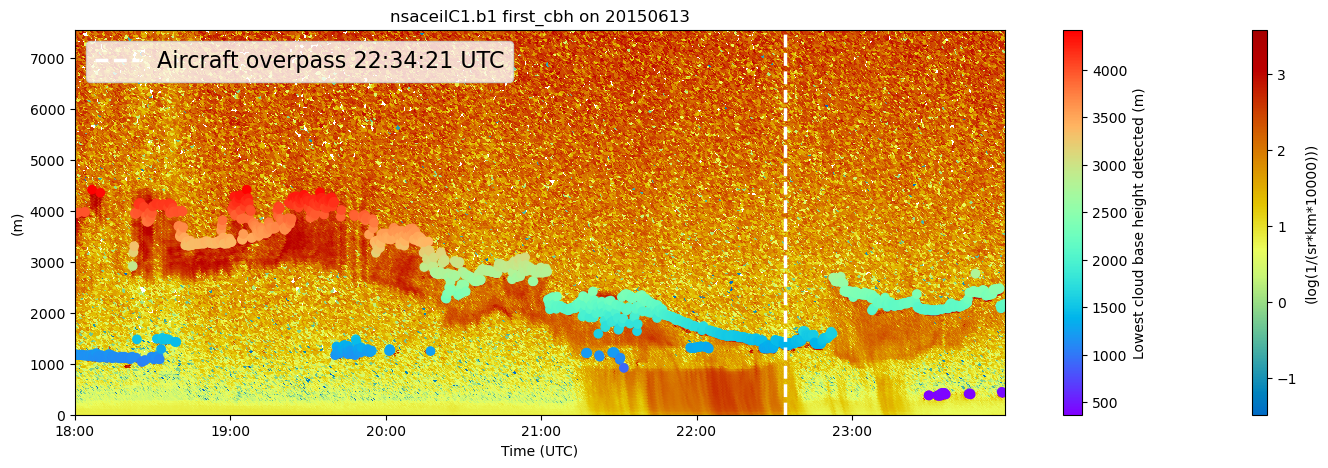

In [64]:
# Plot up ceilometer backscatter using HomeyerRainbow CVD friendly colormap
# The same could be done with keyword 'cmap='HomeyerRainbow'
display = act.plotting.TimeSeriesDisplay(ceil_ds, subplot_shape=(1,), figsize=(15, 5))

my_ax = display.axes[0]

display.plot('backscatter', subplot_index=(0,), cvd_friendly=True)
display.time_height_scatter('first_cbh', subplot_index=(0,))#, cmap=None)
display.set_xrng(xrng=time_rng, subplot_index=(0,))

my_ax.axvline(x=datetime.datetime(2015, 6, 13, 22, 34, 21), color='white', linestyle='--', linewidth=2.5, label='Aircraft overpass 22:34:21 UTC')
my_ax.legend(loc='upper left',fontsize=16)

plt.savefig('/data/home/acresanti/arms-race/nsaceil20150613.png')
plt.show()

In [65]:
#ceil_ds

In [66]:
#print(ceil_ds['time'])

In [67]:
# Set time range
#time_rng=(datetime.datetime(2015, 6, 10, 0, 0), datetime.datetime(2015, 6, 10, 23, 59))

In [68]:
# # Plot up ceilometer backscatter using HomeyerRainbow CVD friendly colormap
# # The same could be done with keyword 'cmap='HomeyerRainbow'
# display = act.plotting.TimeSeriesDisplay(ceil_ds, subplot_shape=(1,), figsize=(15, 5))

# my_ax = display.axes[0]

# display.plot('backscatter', subplot_index=(0,), cvd_friendly=True, time_rng=time_rng)

# #display.time_height_scatter('first_cbh', subplot_index=(0,))#, cmap=None)
# #display.set_xrng(xrng=time_rng, subplot_index=(0,))

# #my_ax.axvline(x=datetime.datetime(2015, 4, 13, 22, 34, 21), color='white', linestyle='--', linewidth=2.5, label='Aircraft overpass 22:34:21 UTC')
# #my_ax.legend(loc='upper left',fontsize=16)

# #plt.savefig('/data/home/acresanti/arms-race/nsaceil20150613.png')

# plt.show()

### Plot without ACT

In [73]:
backscatter.shape

(5400, 252)

In [83]:
len(time)

5400

In [84]:
len(height)

252

/opt/conda/lib/python3.11/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)


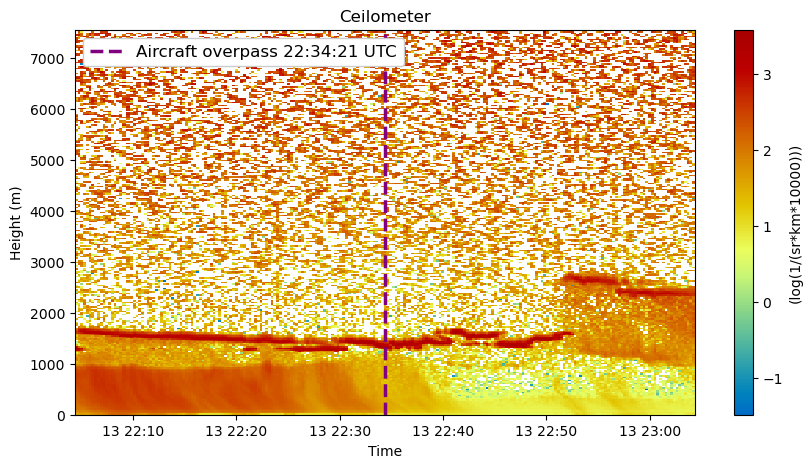

In [101]:
# Plot up ceilometer backscatter using HomeyerRainbow CVD friendly colormap

time = ceil_ds['time']
height = ceil_ds['range']
backscatter = ceil_ds['backscatter']

Y,X = np.meshgrid(height, time)

fig, ax = plt.subplots(figsize=(10, 5))

mesh = ax.pcolormesh(X, Y, backscatter, cmap='HomeyerRainbow')
ax.set_xlabel('Time')
ax.set_ylabel('Height (m)')
ax.set_xlim(datetime.datetime(2015, 6, 13, 22, 4, 21), datetime.datetime(2015, 6, 13, 23, 4, 21))
ax.set_title('Ceilometer')

ax.axvline(x=datetime.datetime(2015, 6, 13, 22, 34, 21), color='purple', linestyle='--', linewidth=2.5, label='Aircraft overpass 22:34:21 UTC')
ax.legend(loc='upper left',fontsize=12,framealpha=1)

plt.colorbar(mesh, ax=ax, label="(log(1/(sr*km*10000)))")

plt.show()

## Create training data

In [31]:
ceil_train = ceil_ds.sel(time=slice('2015-06-10', '2015-06-10'))

In [32]:
ceil_train

<xarray.Dataset> Size: 17MB
Dimensions:                 (time: 5400, bound: 2, range: 252)
Coordinates:
  * time                    (time) datetime64[ns] 43kB 2015-06-10T00:00:08 .....
  * range                   (range) float32 1kB 15.0 45.0 ... 7.545e+03
Dimensions without coordinates: bound
Data variables: (12/34)
    base_time               (time) datetime64[ns] 43kB 2015-06-10 ... 2015-06-10
    time_offset             (time) datetime64[ns] 43kB 2015-06-10T00:00:08 .....
    time_bounds             (time, bound) object 86kB dask.array<chunksize=(5400, 2), meta=np.ndarray>
    range_bounds            (time, range, bound) float32 11MB dask.array<chunksize=(5400, 252, 2), meta=np.ndarray>
    detection_status        (time) float32 22kB dask.array<chunksize=(5400,), meta=np.ndarray>
    status_flag             (time) float32 22kB dask.array<chunksize=(5400,), meta=np.ndarray>
    ...                      ...
    backscatter             (time, range) float32 5MB dask.array<chunksize=(5400, 252), meta=np.ndarray>
    measurement_parameters  (time) |S12 65kB dask.array<chunksize=(5400,), meta=np.ndarray>
    status_string           (time) |S12 65kB dask.array<chunksize=(5400,), meta=np.ndarray>
    lat                     (time) float32 22kB 71.32 71.32 ... 71.32 71.32
    lon                     (time) float32 22kB -156.6 -156.6 ... -156.6 -156.6
    alt                     (time) float32 22kB 8.0 8.0 8.0 8.0 ... 8.0 8.0 8.0
Attributes: (12/31)
    command_line:                ceil_ingest -s nsa -f C1
    Conventions:                 ARM-1.0
    process_version:             ingest-ceil-1.1-0.el6
    dod_version:                 ceil-b1-2.0
    input_source:                /data/collection/nsa/nsaceilC1.00/15060100.DAT
    site_id:                     nsa
    ...                          ...
    qc_bit_3_assessment:         Bad
    history:                     created by user dsmgr on machine ruby at 201...
    _file_dates:                 ['20150601', '20150602', '20150603', '201506...
    _file_times:                 ['000015', '000013', '000011', '000007', '00...
    _datastream:                 nsaceilC1.b1
    _arm_standards_flag:         1

In [34]:
print(ceil_train['range'])

<xarray.DataArray 'range' (range: 252)> Size: 1kB
array([  15.,   45.,   75., ..., 7485., 7515., 7545.], dtype=float32)
Coordinates:
  * range    (range) float32 1kB 15.0 45.0 75.0 ... 7.515e+03 7.545e+03
Attributes:
    long_name:  Distance to the center of the corresponding range bin
    units:      m
    bounds:     range_bounds


In [35]:
heights = np.array(ceil_train['range'])

In [36]:
heights

array([  15.,   45.,   75.,  105.,  135.,  165.,  195.,  225.,  255.,
        285.,  315.,  345.,  375.,  405.,  435.,  465.,  495.,  525.,
        555.,  585.,  615.,  645.,  675.,  705.,  735.,  765.,  795.,
        825.,  855.,  885.,  915.,  945.,  975., 1005., 1035., 1065.,
       1095., 1125., 1155., 1185., 1215., 1245., 1275., 1305., 1335.,
       1365., 1395., 1425., 1455., 1485., 1515., 1545., 1575., 1605.,
       1635., 1665., 1695., 1725., 1755., 1785., 1815., 1845., 1875.,
       1905., 1935., 1965., 1995., 2025., 2055., 2085., 2115., 2145.,
       2175., 2205., 2235., 2265., 2295., 2325., 2355., 2385., 2415.,
       2445., 2475., 2505., 2535., 2565., 2595., 2625., 2655., 2685.,
       2715., 2745., 2775., 2805., 2835., 2865., 2895., 2925., 2955.,
       2985., 3015., 3045., 3075., 3105., 3135., 3165., 3195., 3225.,
       3255., 3285., 3315., 3345., 3375., 3405., 3435., 3465., 3495.,
       3525., 3555., 3585., 3615., 3645., 3675., 3705., 3735., 3765.,
       3795., 3825.,

In [37]:
len(heights)

252

In [44]:
ceil_backscatter = np.array(ceil_train['backscatter'])

/opt/conda/lib/python3.11/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)


In [45]:
print(ceil_backscatter.shape)

(5400, 252)


In [46]:
time = np.array(ceil_train['time'])

In [48]:
print(time)

['2015-06-10T00:00:08.000000000' '2015-06-10T00:00:24.000000000'
 '2015-06-10T00:00:40.000000000' ... '2015-06-10T23:59:17.000000000'
 '2015-06-10T23:59:33.000000000' '2015-06-10T23:59:49.000000000']


In [49]:
len(time)

5400

In [56]:
import xarray as xr
import numpy as np

# Save as netcdf
ds_ceil_save = xr.Dataset(
    data_vars={"backscatter": (["time", "height"], ceil_backscatter)},
    coords={"time": time, "height": heights},
    attrs={"description": "Backscatter from ceilometer"}
)

#ds_ceil_save.to_netcdf("ceilometer10June2015.nc")

In [57]:
ds_ceil_save

<xarray.Dataset> Size: 5MB
Dimensions:      (time: 5400, height: 252)
Coordinates:
  * time         (time) datetime64[ns] 43kB 2015-06-10T00:00:08 ... 2015-06-1...
  * height       (height) float32 1kB 15.0 45.0 75.0 ... 7.515e+03 7.545e+03
Data variables:
    backscatter  (time, height) float32 5MB 0.368 0.5603 0.4523 ... nan nan
Attributes:
    description:  Backscatter from ceilometer

## Create validation data

In [4]:
# Read data
ceil_ds = act.io.arm.read_arm_netcdf(result_ceil)

# Adjust ceilometer data for plotting
ceil_ds = act.corrections.ceil.correct_ceil(ceil_ds, -9999.0)

ERROR 1: PROJ: proj_create_from_database: Open of /opt/conda/share/proj failed


In [5]:
ceil_interest = ceil_ds

In [6]:
heights = np.array(ceil_interest['range'])
time = np.array(ceil_interest['time'])
ceil_backscatter = np.array(ceil_interest['backscatter'])

import xarray as xr
import numpy as np

# Save as netcdf
ds_ceil_save = xr.Dataset(
    data_vars={"backscatter": (["time", "height"], ceil_backscatter)},
    coords={"time": time, "height": heights},
    attrs={"description": "Backscatter from ceilometer"}
)

ds_ceil_save.to_netcdf("ceilometer13June2015.nc")

/opt/conda/lib/python3.11/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)
